# Full Traffic Sign Geolocation Pipeline

This notebook runs the full pipeline in one place:

1. Extract metadata from the capture image.
2. Infer `K_approx`, `T_world_camera_approx`, and `geo_anchor_approx` from that metadata.
3. Run `infer_traffic_sign_geolocation`.

The result is approximate. GPS recovery only makes sense when the image metadata contains a usable geotag and heading/orientation information.

In [1]:
import json
import math
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any
from xml.etree import ElementTree as ET

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import ExifTags, Image
from ultralytics import YOLO

try:
    from transformers import AutoImageProcessor, AutoModel, AutoModelForDepthEstimation
except ImportError as exc:
    raise ImportError('Please install transformers first: pip install transformers') from exc

PROJECT_ROOT = Path('/home/minh-le-vo-nhat/Documents/Minh-DUT/Ky-8-2025-2026/BigData/BTNhom')
CODE_ROOT = PROJECT_ROOT / 'code'
ARTIFACT_DIR = CODE_ROOT / 'cosine_fine_classifier'
DEFAULT_YOLO_MODEL_PATH = CODE_ROOT / 'runs' / 'traffic_sign_yolov8_highlevel' / 'weights' / 'best.pt'
DEFAULT_DEPTH_MODEL_ID = 'depth-anything/Depth-Anything-V2-Metric-Outdoor-Base-hf'
DEFAULT_DINO_MODEL_ID = 'facebook/dinov2-base'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

EXIF_TAGS = ExifTags.TAGS
GPS_TAGS = ExifTags.GPSTAGS

@dataclass
class GeoAnchor:
    lat0: float
    lon0: float
    alt0: float

print(f'Device: {DEVICE}')
print(f'Artifact dir exists: {ARTIFACT_DIR.exists()}')

/home/minh-le-vo-nhat/anaconda3/envs/ts-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Artifact dir exists: True


In [2]:
def rational_to_float(value: Any) -> float | None:
    if value is None:
        return None
    try:
        out = float(value)
        if out != out:
            return None
        return out
    except Exception:
        pass
    if isinstance(value, tuple) and len(value) == 2:
        num, den = value
        den = float(den)
        if den == 0:
            return None
        return float(num) / den
    if hasattr(value, 'numerator') and hasattr(value, 'denominator'):
        den = float(value.denominator)
        if den == 0:
            return None
        return float(value.numerator) / den
    return None


def dms_to_decimal(dms: Any, ref: str | None) -> float | None:
    if dms is None:
        return None
    try:
        d = rational_to_float(dms[0])
        m = rational_to_float(dms[1])
        s = rational_to_float(dms[2])
    except Exception:
        return None
    if d is None or m is None or s is None:
        return None
    value = d + (m / 60.0) + (s / 3600.0)
    if ref in {'S', 'W'}:
        value = -value
    return value


def decode_if_bytes(value: Any) -> Any:
    if isinstance(value, bytes):
        for enc in ('utf-8', 'latin-1'):
            try:
                return value.decode(enc, errors='ignore')
            except Exception:
                continue
    return value


def get_exif_dict(image_path: Path) -> dict[str, Any]:
    image = Image.open(image_path)
    raw_exif = image.getexif()
    exif_named: dict[str, Any] = {}

    for tag_id, value in raw_exif.items():
        tag_name = EXIF_TAGS.get(tag_id, str(tag_id))
        if tag_name in {'GPSInfo', 'ExifOffset'}:
            continue
        exif_named[tag_name] = decode_if_bytes(value)

    try:
        exif_ifd = raw_exif.get_ifd(ExifTags.IFD.Exif)
        for tag_id, value in exif_ifd.items():
            tag_name = EXIF_TAGS.get(tag_id, str(tag_id))
            exif_named.setdefault(tag_name, decode_if_bytes(value))
    except Exception:
        pass

    try:
        gps_ifd = raw_exif.get_ifd(ExifTags.IFD.GPSInfo)
        if gps_ifd:
            gps_named: dict[str, Any] = {}
            for gps_id, gps_val in gps_ifd.items():
                gps_name = GPS_TAGS.get(gps_id, str(gps_id))
                gps_named[gps_name] = decode_if_bytes(gps_val)
            exif_named['GPSInfo'] = gps_named
    except Exception:
        pass

    return exif_named


def extract_xmp_text(image_path: Path) -> str:
    data = image_path.read_bytes()
    start = data.find(b'<x:xmpmeta')
    if start == -1:
        start = data.find(b'<rdf:RDF')
        if start == -1:
            return ''
    end = data.find(b'</x:xmpmeta>')
    if end != -1:
        end += len(b'</x:xmpmeta>')
    else:
        end = data.find(b'</rdf:RDF>')
        if end != -1:
            end += len(b'</rdf:RDF>')
        else:
            end = min(len(data), start + 200000)
    return data[start:end].decode('utf-8', errors='ignore')


def parse_xmp_attributes(xmp_text: str) -> dict[str, str]:
    if not xmp_text.strip():
        return {}
    attrs: dict[str, str] = {}
    for key, val in re.findall(r'([A-Za-z0-9:_.-]+)\s*=\s*"([^"]+)"', xmp_text):
        attrs.setdefault(key, val)
    try:
        root = ET.fromstring(xmp_text)
        for elem in root.iter():
            for k, v in elem.attrib.items():
                attrs.setdefault(k.split('}', 1)[-1], v)
    except Exception:
        pass
    return attrs


def pick_float(candidates: list[str], source: dict[str, Any]) -> float | None:
    for key in candidates:
        if key in source and source[key] not in (None, ''):
            raw = source[key]
            try:
                out = float(raw)
                if out != out:
                    continue
                return out
            except Exception:
                m = re.search(r'-?\d+(?:\.\d+)?', str(raw))
                if m:
                    try:
                        return float(m.group(0))
                    except Exception:
                        pass
    return None


def parse_user_comment_for_pose(comment: Any) -> tuple[float | None, float | None, float | None]:
    if comment is None:
        return (None, None, None)
    if isinstance(comment, (bytes, bytearray)):
        try:
            s = comment.decode('utf-8', errors='ignore')
        except Exception:
            s = str(comment)
    else:
        s = str(comment)
    s = re.sub(r'(?i)^ASCII\x00*', '', s)
    s = s.strip('\x00').strip()
    m = re.search(r'(?i)\bYaw\s*[:=]\s*([-+]?\d+(?:\.\d+)?)\s*,\s*Pitch\s*[:=]\s*([-+]?\d+(?:\.\d+)?)\s*,\s*Roll\s*[:=]\s*([-+]?\d+(?:\.\d+)?)', s)
    if m:
        try:
            return (float(m.group(1)), float(m.group(2)), float(m.group(3)))
        except Exception:
            return (None, None, None)
    return (None, None, None)


def compute_intrinsics(image_width: int, image_height: int, focal_length_mm: float | None, sensor_width_mm: float | None) -> np.ndarray | None:
    if focal_length_mm is None or sensor_width_mm is None:
        return None
    fx = focal_length_mm * (image_width / sensor_width_mm)
    fy = fx
    cx = image_width / 2.0
    cy = image_height / 2.0
    return np.array([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=np.float64)


def extract_metadata_opencamera_style(image_path: str | Path) -> dict[str, Any]:
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f'Image not found: {image_path}')
    image = Image.open(image_path)
    image_width, image_height = image.size

    exif_data = get_exif_dict(image_path)
    gps_exif = exif_data.get('GPSInfo', {}) if isinstance(exif_data.get('GPSInfo'), dict) else {}
    lat = dms_to_decimal(gps_exif.get('GPSLatitude'), gps_exif.get('GPSLatitudeRef'))
    lon = dms_to_decimal(gps_exif.get('GPSLongitude'), gps_exif.get('GPSLongitudeRef'))
    alt = rational_to_float(gps_exif.get('GPSAltitude'))
    alt_ref_raw = gps_exif.get('GPSAltitudeRef')
    if isinstance(alt_ref_raw, (bytes, bytearray)):
        alt_ref_num = int.from_bytes(alt_ref_raw, 'big') if alt_ref_raw else 0
    else:
        alt_ref_num = rational_to_float(alt_ref_raw)
    if alt_ref_num == 1 and alt is not None:
        alt = -alt

    focal_length_mm = rational_to_float(exif_data.get('FocalLength'))
    focal_length_35mm_equiv = rational_to_float(exif_data.get('FocalLengthIn35mmFilm'))

    xmp_text = extract_xmp_text(image_path)
    xmp_attrs = parse_xmp_attributes(xmp_text)

    yaw = pick_float(['PoseHeadingDegrees', 'GPSImgDirection', 'MAPCompassHeading', 'CameraYaw', 'Yaw', 'yaw'], xmp_attrs)
    if yaw is None:
        yaw = rational_to_float(gps_exif.get('GPSImgDirection'))
    pitch = pick_float(['MAPCapturePitch', 'CameraPitch', 'Pitch', 'pitch', 'PosePitchDegrees'], xmp_attrs)
    roll = pick_float(['MAPCaptureRoll', 'CameraRoll', 'Roll', 'roll', 'PoseRollDegrees'], xmp_attrs)

    if 'UserComment' in exif_data:
        yc, pc, rc = parse_user_comment_for_pose(exif_data.get('UserComment'))
        if yaw is None and yc is not None:
            yaw = yc
        if pitch is None and pc is not None:
            pitch = pc
        if roll is None and rc is not None:
            roll = rc

    if lat is None:
        lat = pick_float(['GPSLatitude', 'Latitude', 'MAPLatitude', 'lat'], xmp_attrs)
    if lon is None:
        lon = pick_float(['GPSLongitude', 'Longitude', 'MAPLongitude', 'lon'], xmp_attrs)
    if alt is None:
        alt = pick_float(['GPSAltitude', 'AbsoluteAltitude', 'RelativeAltitude', 'MAPAltitude'], xmp_attrs)

    if focal_length_mm is None:
        focal_length_mm = pick_float(['FocalLength', 'focal_length_mm'], xmp_attrs)
    if focal_length_35mm_equiv is None:
        focal_length_35mm_equiv = pick_float(['FocalLengthIn35mmFilm', 'focal_length_35mm_equiv', 'FocalLength35mm'], xmp_attrs)

    sensor_width_mm = pick_float(['SensorWidth', 'sensor_width_mm', 'ExifSensorWidth', 'sensorWidth'], xmp_attrs)
    sensor_height_mm = pick_float(['SensorHeight', 'sensor_height_mm', 'ExifSensorHeight', 'sensorHeight'], xmp_attrs)
    if sensor_width_mm is None and focal_length_mm is not None and focal_length_35mm_equiv is not None and focal_length_35mm_equiv > 0:
        sensor_width_mm = 36.0 * focal_length_mm / focal_length_35mm_equiv
    if sensor_height_mm is None and sensor_width_mm is not None:
        sensor_height_mm = sensor_width_mm * (float(image_height) / float(image_width))

    K_approx = compute_intrinsics(image_width, image_height, focal_length_mm, sensor_width_mm)
    return {
        'image_path': str(image_path),
        'yaw': yaw,
        'pitch': pitch,
        'roll': roll,
        'gps': {
            'latitude': lat,
            'longitude': lon,
            'altitude_m': alt,
        },
        'image_width': int(image_width),
        'image_height': int(image_height),
        'focal_length_mm': focal_length_mm,
        'sensor_width_mm': sensor_width_mm,
        'sensor_height_mm': sensor_height_mm,
        'focal_length_35mm_equiv': focal_length_35mm_equiv,
        'K_approx': K_approx.tolist() if K_approx is not None else None,
        'metadata_sources': {
            'has_exif': bool(exif_data),
            'has_xmp': bool(xmp_text.strip()),
            'xmp_keys_count': len(xmp_attrs),
        },
    }


def estimate_intrinsic_matrix_from_capture_metadata(
    image_width: int,
    image_height: int,
    focal_length_mm: float | None = None,
    sensor_width_mm: float | None = None,
    sensor_height_mm: float | None = None,
    focal_length_35mm_equiv: float | None = None,
) -> np.ndarray:
    if focal_length_mm is not None and sensor_width_mm is not None and sensor_height_mm is not None:
        fx = float(image_width) * float(focal_length_mm) / float(sensor_width_mm)
        fy = float(image_height) * float(focal_length_mm) / float(sensor_height_mm)
    elif focal_length_35mm_equiv is not None:
        fx = float(image_width) * float(focal_length_35mm_equiv) / 36.0
        fy = fx
    else:
        fx = 0.9 * float(image_width)
        fy = 0.9 * float(image_height)
    cx = float(image_width) / 2.0
    cy = float(image_height) / 2.0
    return np.array([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=np.float64)


def heading_to_rotation_matrix(heading_deg: float, pitch_deg: float = 0.0, roll_deg: float = 0.0) -> np.ndarray:
    yaw = math.radians(90.0 - heading_deg)
    pitch = math.radians(pitch_deg)
    roll = math.radians(roll_deg)
    cy = math.cos(yaw)
    sy = math.sin(yaw)
    cp = math.cos(pitch)
    sp = math.sin(pitch)
    cr = math.cos(roll)
    sr = math.sin(roll)
    Rz = np.array([[cy, -sy, 0.0], [sy, cy, 0.0], [0.0, 0.0, 1.0]], dtype=np.float64)
    Ry = np.array([[cp, 0.0, sp], [0.0, 1.0, 0.0], [-sp, 0.0, cp]], dtype=np.float64)
    Rx = np.array([[1.0, 0.0, 0.0], [0.0, cr, -sr], [0.0, sr, cr]], dtype=np.float64)
    return Rz @ Ry @ Rx


def build_extrinsic_matrix(R_wc: np.ndarray, t_wc: np.ndarray) -> np.ndarray:
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = R_wc
    T[:3, 3] = t_wc.reshape(3)
    return T


def estimate_extrinsic_matrix_from_capture_metadata(
    latitude: float,
    longitude: float,
    altitude_m: float,
    heading_deg: float,
    timestamp: str | None = None,
    speed_mps: float | None = None,
    pitch_deg: float = 0.0,
    roll_deg: float = 0.0,
    camera_height_above_ground_m: float = 1.5,
) -> tuple[np.ndarray, GeoAnchor]:
    _ = timestamp, speed_mps
    anchor = GeoAnchor(lat0=float(latitude), lon0=float(longitude), alt0=float(altitude_m))
    t_wc = np.array([0.0, 0.0, float(camera_height_above_ground_m)], dtype=np.float64)
    R_wc = heading_to_rotation_matrix(heading_deg, pitch_deg=pitch_deg, roll_deg=roll_deg)
    T_world_camera = build_extrinsic_matrix(R_wc, t_wc)
    return T_world_camera, anchor


def build_approximate_calibration_from_metadata(meta: dict[str, Any]) -> tuple[np.ndarray, np.ndarray, GeoAnchor]:
    gps = meta.get('gps', {})
    latitude = gps.get('latitude')
    longitude = gps.get('longitude')
    altitude_m = gps.get('altitude_m')
    if latitude is None or longitude is None:
        raise ValueError('GPS latitude and longitude are required to build geo_anchor_approx.')
    heading = meta.get('yaw') if meta.get('yaw') is not None else 0.0
    pitch = meta.get('pitch') if meta.get('pitch') is not None else 0.0
    roll = meta.get('roll') if meta.get('roll') is not None else 0.0
    if altitude_m is None:
        altitude_m = 0.0
    K_approx = estimate_intrinsic_matrix_from_capture_metadata(
        image_width=int(meta['image_width']),
        image_height=int(meta['image_height']),
        focal_length_mm=meta.get('focal_length_mm'),
        sensor_width_mm=meta.get('sensor_width_mm'),
        sensor_height_mm=meta.get('sensor_height_mm'),
        focal_length_35mm_equiv=meta.get('focal_length_35mm_equiv'),
    )
    T_world_camera_approx, geo_anchor_approx = estimate_extrinsic_matrix_from_capture_metadata(
        latitude=float(latitude),
        longitude=float(longitude),
        altitude_m=float(altitude_m),
        heading_deg=float(heading),
        pitch_deg=float(pitch),
        roll_deg=float(roll),
    )
    return K_approx, T_world_camera_approx, geo_anchor_approx


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return x / np.clip(np.linalg.norm(x, axis=-1, keepdims=True), eps, None)


def load_artifacts(artifact_dir: Path = ARTIFACT_DIR):
    means = np.load(artifact_dir / 'fine_class_means.npz')['mean_vectors'].astype(np.float32)
    with open(artifact_dir / 'index_to_fine_class.json', 'r', encoding='utf-8') as f:
        index_to_fine_json = json.load(f)
    with open(artifact_dir / 'coarse_to_fine_indices.json', 'r', encoding='utf-8') as f:
        coarse_to_indices_json = json.load(f)
    index_to_fine = {int(k): v for k, v in index_to_fine_json.items()}
    coarse_to_indices = {k: [int(x) for x in v] for k, v in coarse_to_indices_json.items()}
    return means, index_to_fine, coarse_to_indices


def load_dinov2(model_id: str = DEFAULT_DINO_MODEL_ID, device: str = DEVICE):
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device)
    model.eval()
    return processor, model


def embed_crop_dinov2(crop_bgr: np.ndarray, processor, model, device: str = DEVICE) -> np.ndarray:
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    inputs = processor(images=crop_rgb, return_tensors='pt', input_data_format='channels_last')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            embedding = outputs.pooler_output
        else:
            embedding = outputs.last_hidden_state[:, 0, :]
        embedding = F.normalize(embedding, dim=1)
    return embedding.squeeze(0).detach().cpu().numpy().astype(np.float32)


def classify_fine_from_coarse(
    crop_bgr: np.ndarray,
    coarse_label: str,
    processor,
    model,
    mean_vectors: np.ndarray,
    index_to_fine_map: dict[int, str],
    coarse_to_indices_map: dict[str, list[int]],
) -> tuple[str | None, float | None]:
    candidate_indices = coarse_to_indices_map.get(coarse_label, [])
    if not candidate_indices:
        return None, None
    emb = embed_crop_dinov2(crop_bgr, processor, model)
    emb = emb / np.clip(np.linalg.norm(emb), 1e-12, None)
    candidate_matrix = mean_vectors[candidate_indices]
    sims = candidate_matrix @ emb
    best_local_idx = int(np.argmax(sims))
    best_global_idx = int(candidate_indices[best_local_idx])
    return index_to_fine_map[best_global_idx], float(sims[best_local_idx])


def load_depth_model(model_id: str = DEFAULT_DEPTH_MODEL_ID, device: str = DEVICE):
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModelForDepthEstimation.from_pretrained(model_id).to(device)
    model.eval()
    return processor, model


def estimate_metric_depth_map(image_bgr: np.ndarray, processor, model, device: str = DEVICE) -> np.ndarray:
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(image_rgb)
    inputs = processor(images=pil_image, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_depth = outputs.predicted_depth
        depth = F.interpolate(predicted_depth.unsqueeze(1), size=image_bgr.shape[:2], mode='bicubic', align_corners=False).squeeze(1)
    return depth.squeeze(0).detach().cpu().numpy().astype(np.float32)


def sample_depth_at_box(depth_map: np.ndarray, box_xyxy: tuple[int, int, int, int], strategy: str = 'median') -> float:
    x1, y1, x2, y2 = box_xyxy
    h, w = depth_map.shape[:2]
    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(0, min(int(x2), w))
    y2 = max(0, min(int(y2), h))
    if x2 <= x1 or y2 <= y1:
        return float('nan')
    region = depth_map[y1:y2, x1:x2]
    region = region[np.isfinite(region)]
    region = region[region > 0]
    if region.size == 0:
        return float('nan')
    if strategy == 'mean':
        return float(region.mean())
    if strategy == 'center':
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        return float(depth_map[cy, cx])
    return float(np.median(region))


def pixel_to_camera(pixel_xy: tuple[float, float], depth_m: float, K: np.ndarray) -> np.ndarray:
    u, v = pixel_xy
    fx = float(K[0, 0])
    fy = float(K[1, 1])
    cx = float(K[0, 2])
    cy = float(K[1, 2])
    z = float(depth_m)
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    return np.array([x, y, z], dtype=np.float64)


def transform_point(T_4x4: np.ndarray, point_xyz: np.ndarray) -> np.ndarray:
    point_h = np.array([point_xyz[0], point_xyz[1], point_xyz[2], 1.0], dtype=np.float64)
    out = T_4x4 @ point_h
    return out[:3] / out[3]


WGS84_A = 6378137.0
WGS84_F = 1.0 / 298.257223563
WGS84_E2 = WGS84_F * (2.0 - WGS84_F)


def geodetic_to_ecef(lat_deg: float, lon_deg: float, alt_m: float) -> np.ndarray:
    lat = math.radians(lat_deg)
    lon = math.radians(lon_deg)
    sin_lat = math.sin(lat)
    cos_lat = math.cos(lat)
    sin_lon = math.sin(lon)
    cos_lon = math.cos(lon)
    n = WGS84_A / math.sqrt(1.0 - WGS84_E2 * sin_lat * sin_lat)
    x = (n + alt_m) * cos_lat * cos_lon
    y = (n + alt_m) * cos_lat * sin_lon
    z = (n * (1.0 - WGS84_E2) + alt_m) * sin_lat
    return np.array([x, y, z], dtype=np.float64)


def ecef_to_geodetic(x: float, y: float, z: float) -> tuple[float, float, float]:
    lon = math.atan2(y, x)
    p = math.sqrt(x * x + y * y)
    lat = math.atan2(z, p * (1.0 - WGS84_E2))
    for _ in range(10):
        sin_lat = math.sin(lat)
        n = WGS84_A / math.sqrt(1.0 - WGS84_E2 * sin_lat * sin_lat)
        alt = p / max(math.cos(lat), 1e-12) - n
        lat_new = math.atan2(z, p * (1.0 - WGS84_E2 * n / (n + alt)))
        if abs(lat_new - lat) < 1e-12:
            lat = lat_new
            break
        lat = lat_new
    sin_lat = math.sin(lat)
    n = WGS84_A / math.sqrt(1.0 - WGS84_E2 * sin_lat * sin_lat)
    alt = p / max(math.cos(lat), 1e-12) - n
    return math.degrees(lat), math.degrees(lon), alt


def enu_rotation_matrix(lat0_deg: float, lon0_deg: float) -> np.ndarray:
    lat0 = math.radians(lat0_deg)
    lon0 = math.radians(lon0_deg)
    sin_lat = math.sin(lat0)
    cos_lat = math.cos(lat0)
    sin_lon = math.sin(lon0)
    cos_lon = math.cos(lon0)
    return np.array([[-sin_lon, cos_lon, 0.0], [-sin_lat * cos_lon, -sin_lat * sin_lon, cos_lat], [cos_lat * cos_lon, cos_lat * sin_lon, sin_lat]], dtype=np.float64)


def enu_to_ecef(enu_xyz: np.ndarray, anchor: GeoAnchor) -> np.ndarray:
    ecef_anchor = geodetic_to_ecef(anchor.lat0, anchor.lon0, anchor.alt0)
    rot = enu_rotation_matrix(anchor.lat0, anchor.lon0)
    return ecef_anchor + rot.T @ enu_xyz.astype(np.float64)


def world_to_gps(world_xyz: np.ndarray, anchor: GeoAnchor) -> tuple[float, float, float]:
    ecef = enu_to_ecef(world_xyz, anchor)
    return ecef_to_geodetic(float(ecef[0]), float(ecef[1]), float(ecef[2]))


def infer_traffic_sign_geolocation(
    image_path: str | Path,
    K_approx: np.ndarray,
    T_world_camera_approx: np.ndarray,
    geo_anchor_approx: GeoAnchor,
    yolo_model_path: str | Path = DEFAULT_YOLO_MODEL_PATH,
    conf: float = 0.25,
    depth_sample_strategy: str = 'median',
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    image_path = Path(image_path)
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f'Could not read image: {image_path}')
    if K_approx is None:
        raise ValueError('K_approx is required.')
    if T_world_camera_approx is None:
        raise ValueError('T_world_camera_approx is required.')
    if geo_anchor_approx is None:
        raise ValueError('geo_anchor_approx is required.')

    mean_vectors, index_to_fine_map, coarse_to_indices_map = load_artifacts()
    dino_processor, dino_model = load_dinov2()
    depth_processor, depth_model = load_depth_model()

    yolo_model = YOLO(str(yolo_model_path))
    result = yolo_model.predict(source=str(image_path), conf=conf, verbose=False)[0]
    yolo_coarse_names = [result.names[i] for i in range(len(result.names))] if hasattr(result, 'names') and result.names is not None else None
    if yolo_coarse_names is None:
        raise ValueError('YOLO class names are required.')

    depth_map = estimate_metric_depth_map(image_bgr, depth_processor, depth_model)
    image_display = image_bgr.copy()
    rows: list[dict[str, Any]] = []

    for det_id, box in enumerate(result.boxes):
        coarse_idx = int(box.cls.item())
        coarse_label = yolo_coarse_names[coarse_idx]
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = max(0, x2), max(0, y2)
        if x2 <= x1 or y2 <= y1:
            continue
        crop = image_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        fine_label, cosine_sim = classify_fine_from_coarse(crop, coarse_label, dino_processor, dino_model, mean_vectors, index_to_fine_map, coarse_to_indices_map)
        depth_m = sample_depth_at_box(depth_map, (x1, y1, x2, y2), strategy=depth_sample_strategy)
        if not np.isfinite(depth_m) or depth_m <= 0:
            continue
        center_u = float((x1 + x2) / 2.0)
        center_v = float((y1 + y2) / 2.0)
        camera_xyz = pixel_to_camera((center_u, center_v), depth_m, K_approx)
        world_xyz = transform_point(T_world_camera_approx, camera_xyz)
        lat, lon, alt = world_to_gps(world_xyz, geo_anchor_approx)

        cv2.rectangle(image_display, (x1, y1), (x2, y2), (0, 0, 255), 2)
        label_text = f'{coarse_label} | {fine_label or "unknown"} | z={depth_m:.2f}m'
        cv2.putText(image_display, label_text, (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2, cv2.LINE_AA)

        rows.append({
            'det_id': det_id,
            'coarse_label': coarse_label,
            'fine_label': fine_label,
            'cosine_similarity': cosine_sim,
            'confidence_yolo': float(box.conf.item()),
            'bbox_x1': int(x1),
            'bbox_y1': int(y1),
            'bbox_x2': int(x2),
            'bbox_y2': int(y2),
            'depth_m': float(depth_m),
            'camera_x_m': float(camera_xyz[0]),
            'camera_y_m': float(camera_xyz[1]),
            'camera_z_m': float(camera_xyz[2]),
            'world_x_m': float(world_xyz[0]),
            'world_y_m': float(world_xyz[1]),
            'world_z_m': float(world_xyz[2]),
            'latitude': float(lat),
            'longitude': float(lon),
            'altitude_m': float(alt),
        })

    return pd.DataFrame(rows), depth_map, image_display


In [3]:
# Run the full pipeline in sequence.
# Replace the path if your capture image lives somewhere else.
image_path = PROJECT_ROOT / 'OpenCamera' / 'IMG_20260527_144859.jpg'

meta = extract_metadata_opencamera_style(image_path)
K_approx, T_world_camera_approx, geo_anchor_approx = build_approximate_calibration_from_metadata(meta)

print('Metadata:')
print(json.dumps(meta, indent=2, ensure_ascii=False))
print()
print('K_approx:')
print(K_approx)
print()
print('T_world_camera_approx:')
print(T_world_camera_approx)
print()
print('geo_anchor_approx:')
print(geo_anchor_approx)

df_pred, depth_map, image_display = infer_traffic_sign_geolocation(
    image_path=image_path,
    K_approx=K_approx,
    T_world_camera_approx=T_world_camera_approx,
    geo_anchor_approx=geo_anchor_approx,
)

print()
print('Predictions:')
print(df_pred.to_string(index=False) if len(df_pred) else 'No detections passed the filters.')

Metadata:
{
  "image_path": "/home/minh-le-vo-nhat/Documents/Minh-DUT/Ky-8-2025-2026/BigData/BTNhom/OpenCamera/IMG_20260527_144859.jpg",
  "yaw": 194.45,
  "pitch": 1.4701388789160366,
  "roll": -2.5537195020540366,
  "gps": {
    "latitude": 16.075016,
    "longitude": 108.1553343,
    "altitude_m": 1.0
  },
  "image_width": 4000,
  "image_height": 3000,
  "focal_length_mm": 4.6,
  "sensor_width_mm": 6.624,
  "sensor_height_mm": 4.968,
  "focal_length_35mm_equiv": 25.0,
  "K_approx": [
    [
      2777.777777777778,
      0.0,
      2000.0
    ],
    [
      0.0,
      2777.777777777778,
      1500.0
    ],
    [
      0.0,
      0.0,
      1.0
    ]
  ],
  "metadata_sources": {
    "has_exif": true,
    "has_xmp": false,
    "xmp_keys_count": 0
  }
}

K_approx:
[[     2777.8           0        2000]
 [          0      2777.8        1500]
 [          0           0           1]]

T_world_camera_approx:
[[   -0.24945     0.96769    0.036751           0]
 [   -0.96805    -0.24818   -0.03

Loading weights: 100%|██████████| 287/287 [00:00<00:00, 4051.50it/s]



Predictions:
 det_id coarse_label                 fine_label  cosine_similarity  confidence_yolo  bbox_x1  bbox_y1  bbox_x2  bbox_y2   depth_m  camera_x_m  camera_y_m  camera_z_m  world_x_m  world_y_m  world_z_m  latitude  longitude  altitude_m
      0   regulatory regulatory--no-parking--g1            0.61022         0.747869     1289     1855     1398     1970 39.264221   -9.279706    5.830737   39.264221   9.400185   6.125042  40.690686 16.075071 108.155422   41.690696


(np.float64(-0.5), np.float64(2999.5), np.float64(3999.5), np.float64(-0.5))

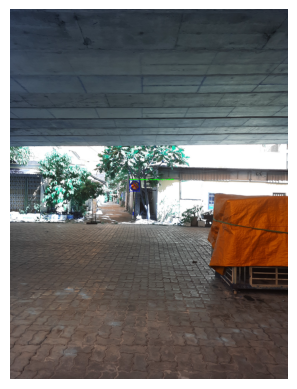

In [6]:
import matplotlib.pyplot as plt

plt.imshow(image_display)
plt.axis('off')